# Uchida Lab - Phillips 2025 NWB Demo

This notebook demonstrates how to load and visualize a single session from the **Uchida Lab
Phillips 2025 / SFARI ARC** dataset converted to NWB.

**Experimental overview:**  
Freely behaving rats (autism rat models, SFARI ARC) were recorded with:
- **Fiber photometry** - Doric BBC300 BFPD camera, 2 frequency-multiplexed LED excitation
  channels (EXC1 and EXC2), 3 fiber ROIs per session
- **3D pose estimation** - social-DANNCE (23 keypoints, ~50 Hz)
- **6-camera behavioral video** - synchronized via pCampi (LabVIEW)

**Sections:**
1. Setup & load session
2. Session metadata
3. FiberPhotometryTable - channel configuration
4. Raw fiber photometry traces
5. Processed dF/F traces
6. Sync TTL channels
7. DANNCE 3D pose estimation

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pynwb import NWBHDF5IO

In [2]:
# Update this path to point to your converted NWB file
NWB_FILE_PATH = "H://uchida-nwbfiles/nwb_stub/sub-M4_ses-240624_135840_M4.nwb"

io = NWBHDF5IO(NWB_FILE_PATH, "r", load_namespaces=True)
nwbfile = io.read()
print("Loaded:", NWB_FILE_PATH)

Loaded: H://uchida-nwbfiles/nwb_stub/sub-M4_ses-240624_135840_M4.nwb


## 2. Session Metadata

In [3]:
print(f"Session ID         : {nwbfile.session_id}")
print(f"Session start      : {nwbfile.session_start_time}")
print(f"Institution        : {nwbfile.institution}")
print(f"Lab                : {nwbfile.lab}")
print()
subj = nwbfile.subject
print(f"Subject ID         : {subj.subject_id}")
print(f"Species            : {subj.species}")
print(f"Sex                : {subj.sex}")
print(f"Description        : {subj.description}")

Session ID         : 240624_135840_M4
Session start      : 2024-06-24 13:58:40-04:00
Institution        : Harvard University
Lab                : Uchida

Subject ID         : M4
Species            : Rattus norvegicus
Sex                : U
Description        : Autism rat model M4 (SFARI ARC). Metadata TBD.


## 3. FiberPhotometryTable - Channel Configuration

The `FiberPhotometryTable` (in `lab_meta_data`) stores one row per recording channel
linking together the optical fiber, excitation source, photodetector, and indicator.

In [4]:
fp_table = nwbfile.lab_meta_data["fiber_photometry"].fiber_photometry_table
print(f"FiberPhotometryTable: {len(fp_table)} rows")
print(f"Columns: {fp_table.colnames}\n")

for i in range(len(fp_table)):
    fiber = fp_table["optical_fiber"][i].name
    exc   = fp_table["excitation_source"][i].name
    loc   = fp_table["location"][i]
    exc_wl = fp_table["excitation_wavelength_in_nm"][i]
    print(f"  Row {i}: fiber={fiber}  source={exc}  location={loc}  exc_wl={exc_wl} nm")

FiberPhotometryTable: 6 rows
Columns: ('location', 'excitation_wavelength_in_nm', 'emission_wavelength_in_nm', 'indicator', 'optical_fiber', 'excitation_source', 'photodetector')

  Row 0: fiber=optical_fiber_ROI01  source=excitation_source_EXC1  location=ROI01  exc_wl=0.0 nm
  Row 1: fiber=optical_fiber_ROI01  source=excitation_source_EXC2  location=ROI01  exc_wl=0.0 nm
  Row 2: fiber=optical_fiber_ROI02  source=excitation_source_EXC1  location=ROI02  exc_wl=0.0 nm
  Row 3: fiber=optical_fiber_ROI02  source=excitation_source_EXC2  location=ROI02  exc_wl=0.0 nm
  Row 4: fiber=optical_fiber_ROI03  source=excitation_source_EXC1  location=ROI03  exc_wl=0.0 nm
  Row 5: fiber=optical_fiber_ROI03  source=excitation_source_EXC2  location=ROI03  exc_wl=0.0 nm


## 4. Raw Fiber Photometry Traces

Six raw demodulated fluorescence traces: one per (ROI, excitation channel) pair.
EXC1 and EXC2 are frequency-multiplexed LEDs running at 30 Hz each.

In [5]:
raw_keys = [k for k in nwbfile.acquisition if k.startswith("FiberPhotometry_")]
raw_keys.sort()
print("Raw photometry series:", raw_keys)

Raw photometry series: ['FiberPhotometry_EXC1_ROI01', 'FiberPhotometry_EXC1_ROI02', 'FiberPhotometry_EXC1_ROI03', 'FiberPhotometry_EXC2_ROI01', 'FiberPhotometry_EXC2_ROI02', 'FiberPhotometry_EXC2_ROI03']


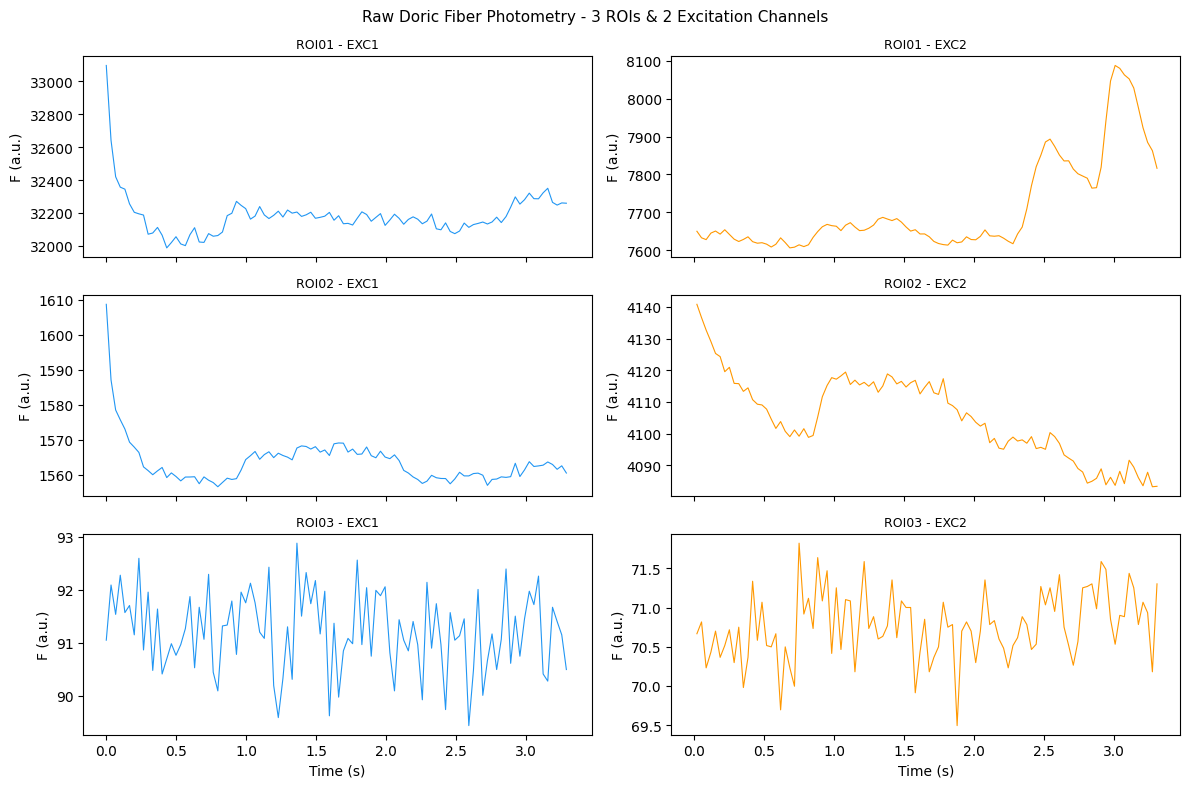

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
colors = {"EXC1": "#2196F3", "EXC2": "#FF9800"}

for ax_row, roi in enumerate(["ROI01", "ROI02", "ROI03"]):
    for ax_col, exc in enumerate(["EXC1", "EXC2"]):
        key = f"FiberPhotometry_{exc}_{roi}"
        series = nwbfile.acquisition[key]
        t = series.timestamps[:]
        d = series.data[:]
        ax = axes[ax_row, ax_col]
        ax.plot(t, d, color=colors[exc], lw=0.8)
        ax.set_title(f"{roi} - {exc}", fontsize=9)
        ax.set_ylabel("F (a.u.)")
        if ax_row == 2:
            ax.set_xlabel("Time (s)")

fig.suptitle("Raw Doric Fiber Photometry - 3 ROIs & 2 Excitation Channels", fontsize=11)
fig.tight_layout()
plt.show()

## 5. Processed dF/F Traces

Lab-processed signals from `interpolated_campy_and_doric_data.mat`, interpolated to the
video frame rate (~50 Hz) by the Uchida lab MATLAB pipeline.

In [7]:
ophys = nwbfile.processing["ophys"]
proc_keys = list(ophys.data_interfaces.keys())
print("Processed signals:", proc_keys)

Processed signals: ['dff_resG', 'dff_resG2', 'fit_baseG', 'fit_baseG2', 'rawG', 'rawGR', 'rawR', 'rawTd']


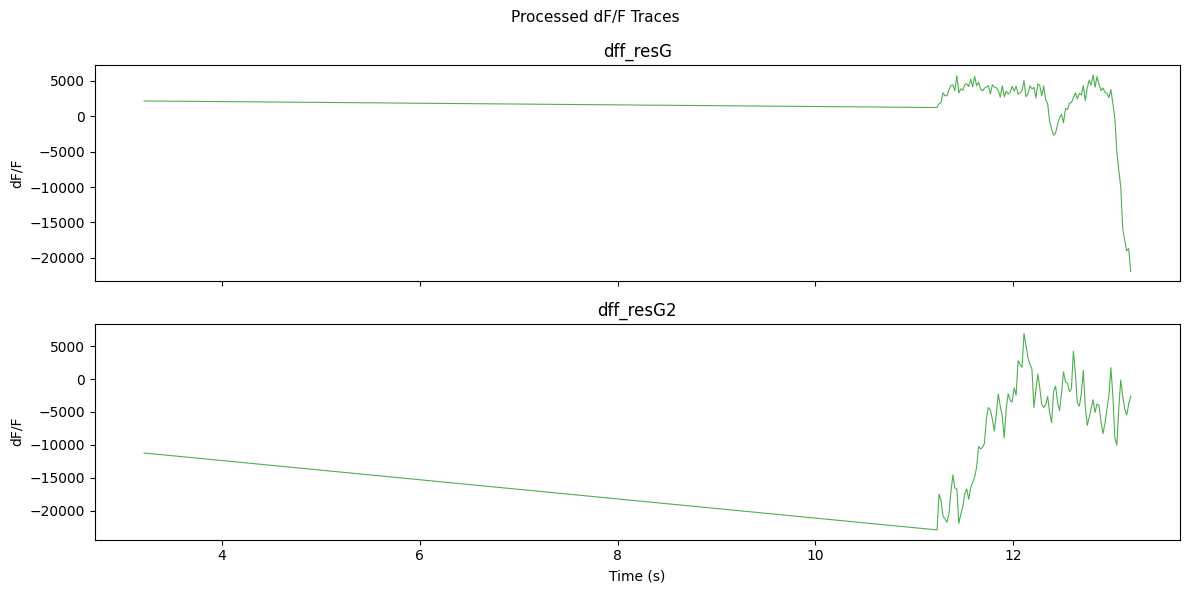

In [8]:
dff_keys = [k for k in proc_keys if k.startswith("dff_")]

fig, axes = plt.subplots(len(dff_keys), 1, figsize=(12, 3 * len(dff_keys)), sharex=True)
if len(dff_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, dff_keys):
    series = ophys[key]
    t = series.timestamps[:]
    d = series.data[:]
    ax.plot(t, d, color="#4CAF50", lw=0.8)
    ax.set_title(key)
    ax.set_ylabel("dF/F")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Processed dF/F Traces", fontsize=11)
fig.tight_layout()
plt.show()

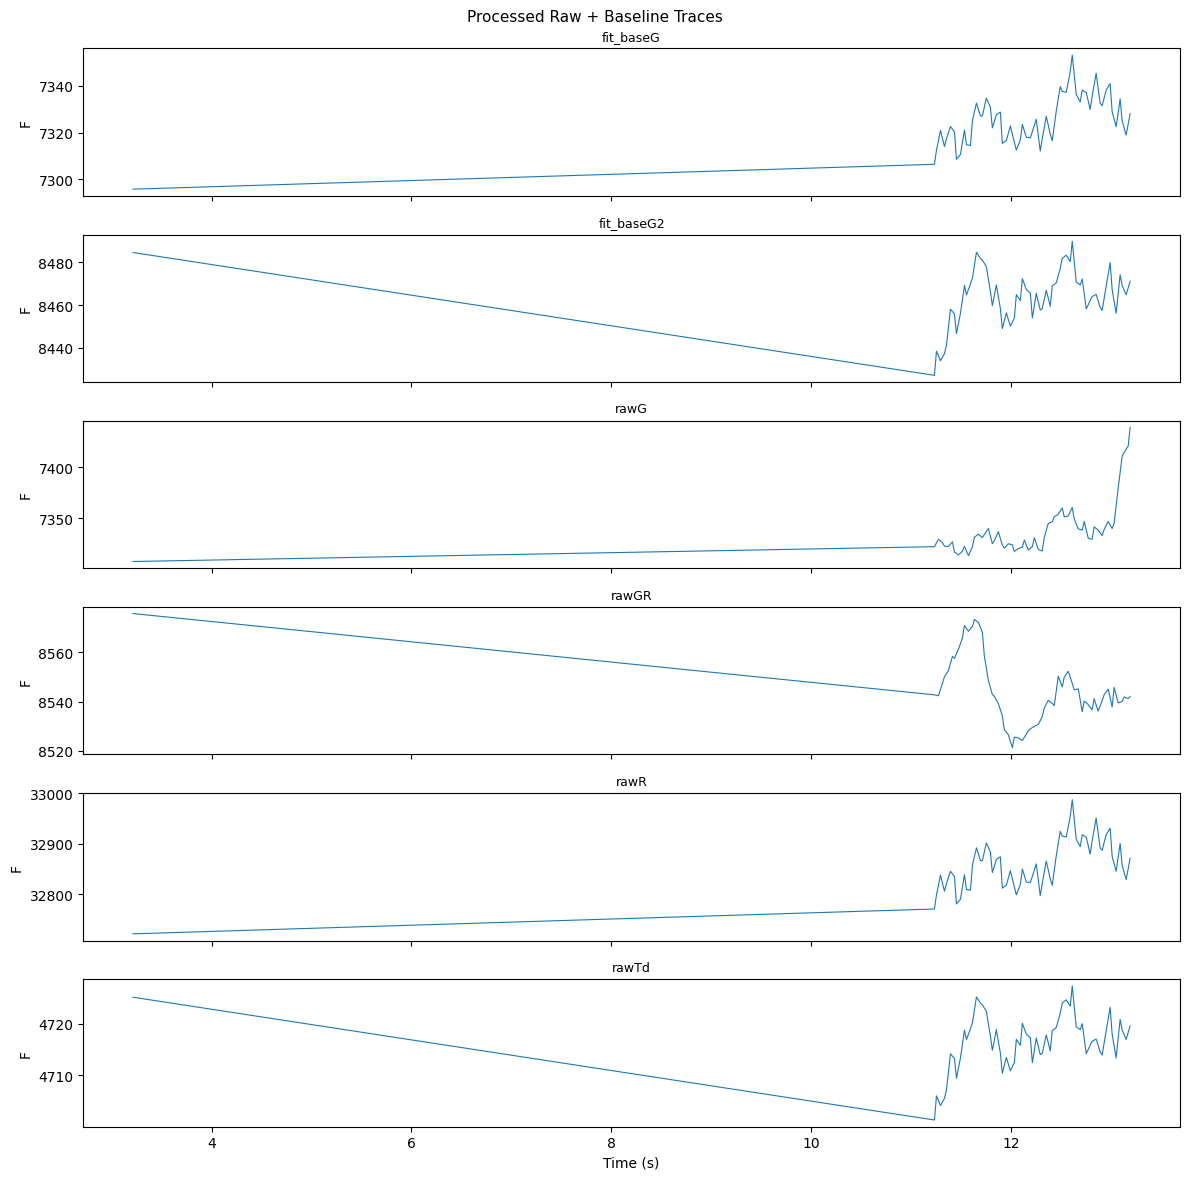

In [9]:
# Raw processed channels (rawG, rawGR, rawR, rawTd) and fitted baselines
other_keys = [k for k in proc_keys if not k.startswith("dff_")]

fig, axes = plt.subplots(len(other_keys), 1, figsize=(12, 2 * len(other_keys)), sharex=True)
if len(other_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, other_keys):
    series = ophys[key]
    t = series.timestamps[:]
    d = series.data[:]
    ax.plot(t, d, lw=0.8)
    ax.set_title(key, fontsize=9)
    ax.set_ylabel("F")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Processed Raw + Baseline Traces", fontsize=11)
fig.tight_layout()
plt.show()

## 6. Synchronization TTL Channels

Two 1 kHz TTL channels recorded by pCampi (LabVIEW):
- **campy_trigger**: rising edges mark each camera frame exposure
- **rbfmc_frames**: rising edges mark each Doric fiber photometry frame

These are used during conversion to align the Doric clock to the video clock.

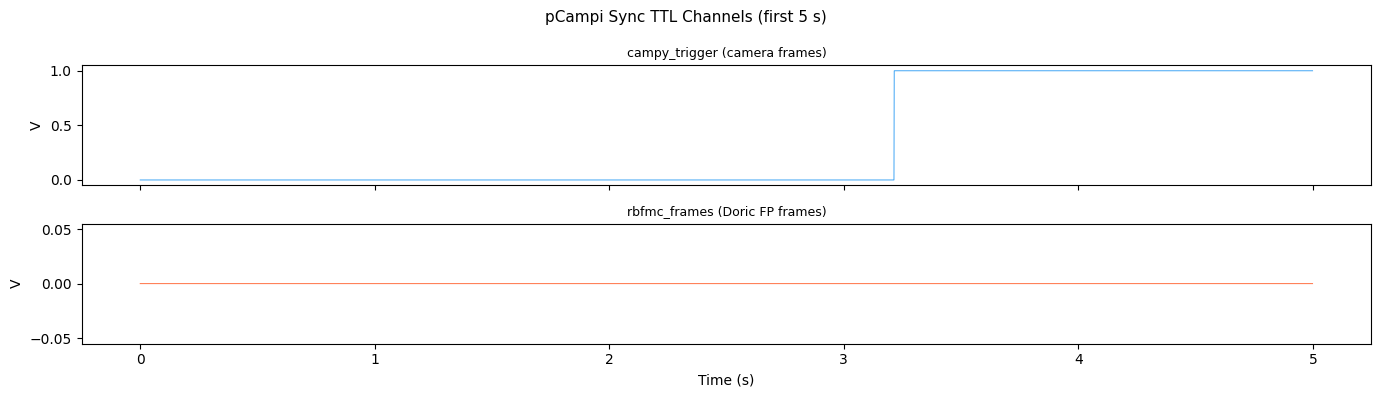

In [10]:
campy = nwbfile.acquisition["SyncTTL_campy_trigger"]
rbfmc = nwbfile.acquisition["SyncTTL_rbfmc_frames"]

# These series use rate + starting_time (no timestamps array)
def _timevec(series):
    if series.timestamps is not None:
        return series.timestamps[:]
    n = series.data.shape[0]
    return series.starting_time + np.arange(n) / series.rate

campy_t = _timevec(campy)
mask = campy_t < campy_t[0] + 5.0

fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)

for ax, series, label, color in [
    (axes[0], campy, "campy_trigger (camera frames)", "#2196F3"),
    (axes[1], rbfmc, "rbfmc_frames (Doric FP frames)", "#FF5722"),
]:
    t = _timevec(series)[mask]
    d = series.data[:][mask]
    ax.plot(t, d, color=color, lw=0.6)
    ax.set_ylabel("V")
    ax.set_title(label, fontsize=9)

axes[1].set_xlabel("Time (s)")
fig.suptitle("pCampi Sync TTL Channels (first 5 s)", fontsize=11)
fig.tight_layout()
plt.show()

## 7. DANNCE 3D Pose Estimation

Social-DANNCE 3D keypoint coordinates for 23 body landmarks at ~50 Hz,
stored in `processing/behavior/PoseEstimationDANNCE_M4`.

In [16]:
behavior = nwbfile.processing["behavior"]
behavior

Data type,float64
Shape,"(100, 3)"
Array size,2.34 KiB
Chunk shape,"(100, 3)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),2400
Compressed size (bytes),1361
Compression ratio,1.763409257898604
Data type,float64
Shape,"(100,)"


In [18]:
pose = behavior["PoseEstimationSDANNCE"]
series_names = list(pose.pose_estimation_series.keys())
print(f"PoseEstimation: {len(series_names)} keypoints")
print("First 5 keypoints:", series_names[:5])

PoseEstimation: 23 keypoints
First 5 keypoints: ['PoseEstimationSeriesLandmark0', 'PoseEstimationSeriesLandmark1', 'PoseEstimationSeriesLandmark10', 'PoseEstimationSeriesLandmark11', 'PoseEstimationSeriesLandmark12']


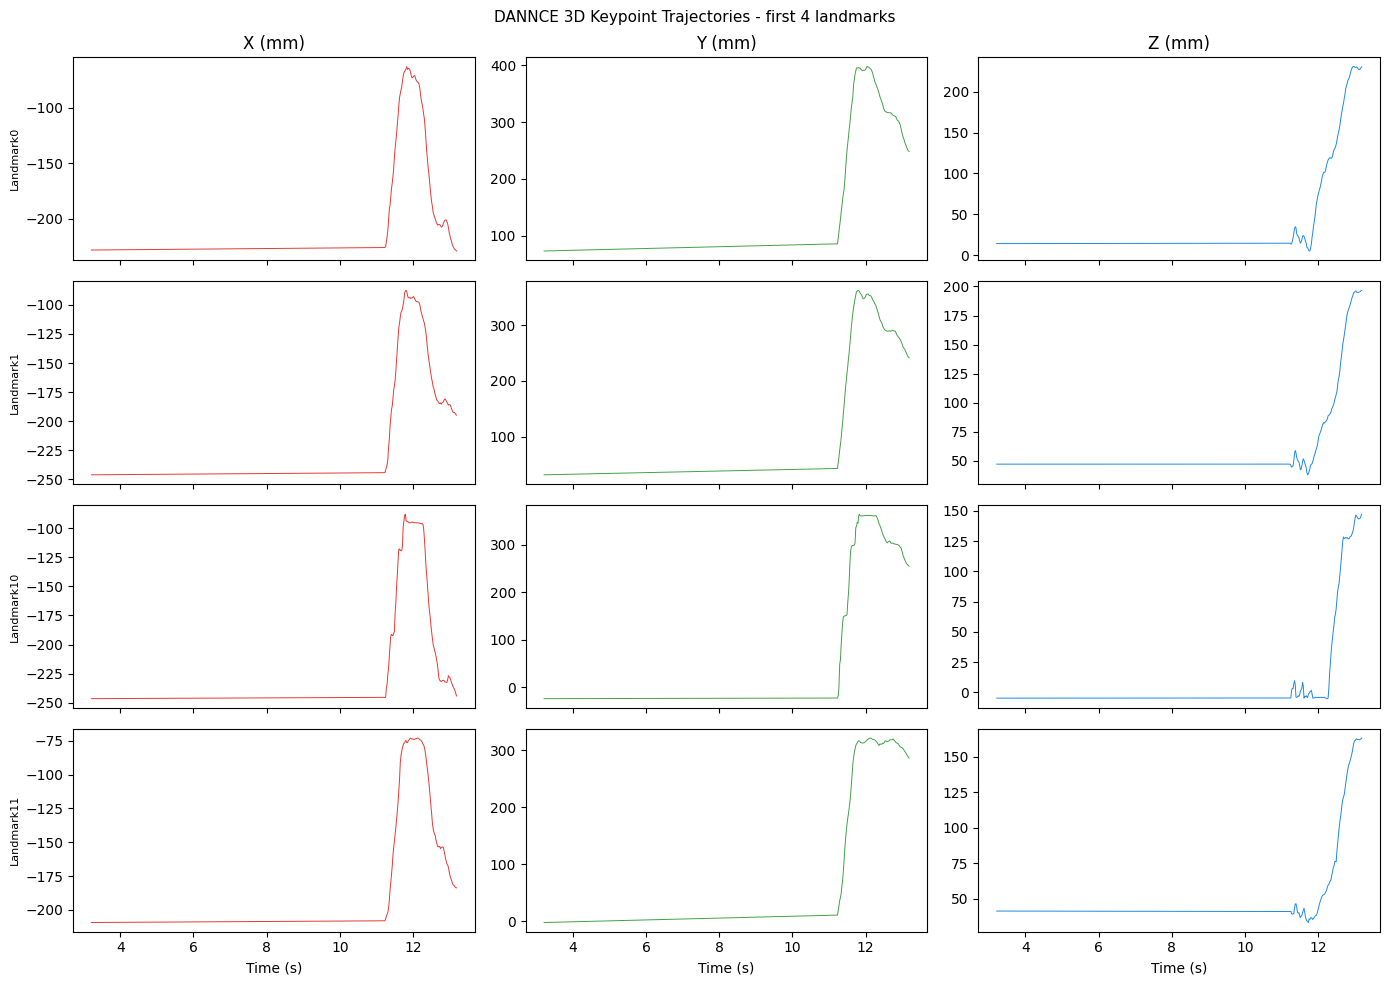

In [19]:
# Plot x/y/z trajectories for the first 4 keypoints
n_show = min(4, len(series_names))
fig, axes = plt.subplots(n_show, 3, figsize=(14, 2.5 * n_show), sharex=True)

for row_idx, name in enumerate(series_names[:n_show]):
    pes = pose.pose_estimation_series[name]
    t = pes.timestamps[:]
    xyz = pes.data[:]  # (n_frames, 3)
    for col_idx, (coord, color) in enumerate([("X", "#E53935"), ("Y", "#43A047"), ("Z", "#1E88E5")]):
        ax = axes[row_idx, col_idx]
        ax.plot(t, xyz[:, col_idx], lw=0.7, color=color)
        if row_idx == 0:
            ax.set_title(f"{coord} (mm)")
        if col_idx == 0:
            ax.set_ylabel(name.replace("PoseEstimationSeries", ""), fontsize=8)
        if row_idx == n_show - 1:
            ax.set_xlabel("Time (s)")

fig.suptitle("DANNCE 3D Keypoint Trajectories - first 4 landmarks", fontsize=11)
fig.tight_layout()
plt.show()

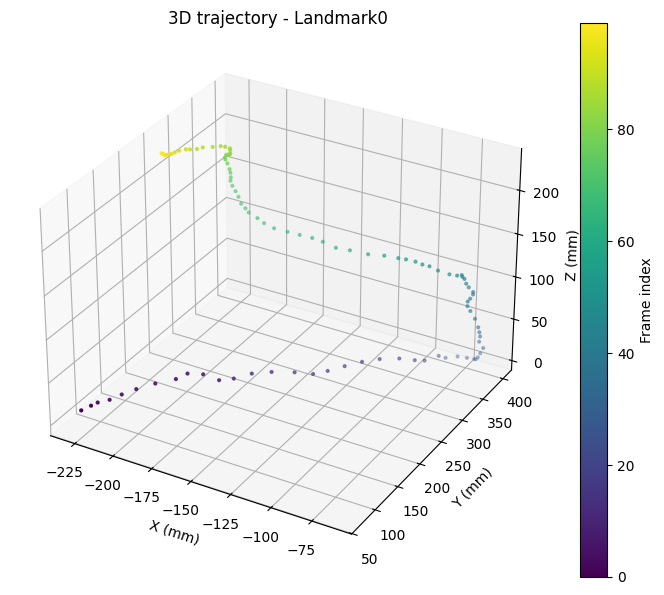

In [20]:
# 3D scatter of one keypoint (e.g., landmark_0) coloured by time
pes0 = pose.pose_estimation_series[series_names[0]]
xyz = pes0.data[:]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
                c=np.arange(len(xyz)), cmap="viridis", s=4)
plt.colorbar(sc, ax=ax, label="Frame index")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title(f"3D trajectory - {series_names[0].replace('PoseEstimationSeries', '')}")
plt.tight_layout()
plt.show()

## 8. Video References

Six `ImageSeries` objects in `nwbfile.acquisition` store external file references to the
`.mp4` videos. The pixel data is not embedded in the NWB file - this keeps file size
manageable for large multi-camera recordings.

In [21]:
for cam in ["Camera1", "Camera2", "Camera3", "Camera4", "Camera5", "Camera6"]:
    series = nwbfile.acquisition[cam]
    n_frames = len(series.timestamps[:])
    ext_file = series.external_file[0] if hasattr(series, "external_file") else "embedded"
    print(f"{cam}: {n_frames} frames  |  {ext_file}")

Camera1: 90074 frames  |  H:\Uchida-CN-data-share\Hannah_data\M4-M7\Lone_data\day_1\M4\videos\Camera1\0.mp4
Camera2: 90074 frames  |  H:\Uchida-CN-data-share\Hannah_data\M4-M7\Lone_data\day_1\M4\videos\Camera2\0.mp4
Camera3: 90074 frames  |  H:\Uchida-CN-data-share\Hannah_data\M4-M7\Lone_data\day_1\M4\videos\Camera3\0.mp4
Camera4: 90074 frames  |  H:\Uchida-CN-data-share\Hannah_data\M4-M7\Lone_data\day_1\M4\videos\Camera4\0.mp4
Camera5: 90074 frames  |  H:\Uchida-CN-data-share\Hannah_data\M4-M7\Lone_data\day_1\M4\videos\Camera5\0.mp4
Camera6: 90074 frames  |  H:\Uchida-CN-data-share\Hannah_data\M4-M7\Lone_data\day_1\M4\videos\Camera6\0.mp4


In [22]:
io.close()
print("Done.")

Done.
